In [1]:
import langchain
langchain.__version__

'1.3.9'

In [2]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
#response = llm.invoke("Tell me about Rohit sharma in 3 bullet points")
#response

AIMessage(content='Here are three bullet points about Rohit Sharma:\n\n* Rohit Sharma is an Indian international cricketer who serves as the captain of the India national team in all formats of the game. He is known for his exceptional batting skills, particularly in limited-overs cricket.\n* Rohit Sharma has achieved numerous records and milestones in his career, including being the highest individual scorer in ODIs with a score of 264 runs, and becoming the first batsman to score five centuries in a single World Cup edition.\n* Rohit Sharma has also been successful in the Indian Premier League (IPL), where he captains the Mumbai Indians team and has led them to multiple championships. He is considered one of the most successful captains in the history of the IPL.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 47, 'total_tokens': 198, 'completion_time': 0.496491196, 'completion_tokens_details': None, 'prompt_time': 0.001691996, 'p

In [6]:
from langchain.tools import tool

@tool
def get_weather(city:str) -> str:
    """ Get the weather for a city """
    return f"The weather in {city} is sunny with a high of 25 degrees Celsius."

In [25]:
get_weather

StructuredTool(name='get_weather', description='Get the weather for a city', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x00000267595A1580>)

In [15]:
agent = create_agent(
    model=llm,
    #tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

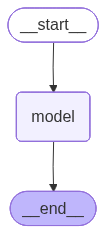

In [16]:
agent

In [17]:
response = agent.invoke({"messages":[{"role": "user", "content": "what is the weather in Pune City?"}]})

In [18]:
response

{'messages': [HumanMessage(content='what is the weather in Pune City?', additional_kwargs={}, response_metadata={}, id='7ea3cdaa-2e44-4418-b198-4af3e8660ede'),
  AIMessage(content="I'm a large language model, I don't have real-time access to current weather conditions. But I can provide you with general information about the climate in Pune City, India.\n\nPune has a tropical wet and dry climate, with three main seasons: summer, monsoon, and winter.\n\n* Summer (March to May): The temperature can range from 20°C to 40°C (68°F to 104°F), with high humidity.\n* Monsoon (June to September): The city experiences heavy rainfall during this period, with an average annual rainfall of around 700 mm (28 in).\n* Winter (October to February): The temperature cools down, ranging from 10°C to 25°C (50°F to 77°F), with low humidity.\n\nIf you're looking for the current weather in Pune City, I recommend checking a reliable weather website or app, such as:\n\n* AccuWeather\n* Weather.com\n* India Mete

In [13]:
response = agent.invoke({"messages":"what is the capital of India?"})

In [14]:
response

{'messages': [HumanMessage(content='what is the capital of India?', additional_kwargs={}, response_metadata={}, id='4357c752-8ac8-4497-aac3-818c21a4c5f6'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 224, 'total_tokens': 233, 'completion_time': 0.026755317, 'completion_tokens_details': None, 'prompt_time': 0.011534748, 'prompt_tokens_details': None, 'queue_time': 0.161801762, 'total_time': 0.038290065}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed517-2a4b-71a3-b77e-ed208e15d2c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 224, 'output_tokens': 9, 'total_tokens': 233})]}